In [95]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl textblob transformers torch -q


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\mp2pf\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [96]:
 # =============================================================================
# CELL 1: INSTALL & IMPORT LIBRARY
# =============================================================================

# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import time
import os

# Import library Machine Learning
from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                       cross_val_score, cross_validate,
                                       cross_val_predict, learning_curve)
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.metrics          import (classification_report, roc_auc_score,
                                       confusion_matrix, accuracy_score, f1_score,
                                       roc_curve)
from sklearn.svm              import SVC
from sklearn.pipeline         import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble         import RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from xgboost                  import XGBClassifier

# Import untuk Excel Report
from openpyxl                        import Workbook
from openpyxl.styles                 import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe        import dataframe_to_rows
from datetime                        import datetime

# Matikan warning
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("✅ Semua library berhasil di-import!")
print("=" * 60)
print(f"📊 Pandas  : {pd.__version__}")
print(f"🔢 NumPy   : {np.__version__}")
print(f"🤖 Sklearn : {__import__('sklearn').__version__}")
print("=" * 60)


✅ Semua library berhasil di-import!
📊 Pandas  : 3.0.2
🔢 NumPy   : 2.4.4
🤖 Sklearn : 1.8.0


In [97]:
# =============================================================================
# CELL 2: LOAD DATA
# =============================================================================

# Load data
df = pd.read_csv('../data/raw/churn_data.csv')

print(f"📊 Shape of dataset: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")
print("\n🔍 Preview Data:")
df.head()

📊 Shape of dataset: (36992, 28)
📋 Columns: ['age', 'gender', 'security_no', 'region_category', 'joining_date', 'joined_through_referral', 'referral_id', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'last_visit_time', 'days_since_last_login', 'avg_session_duration', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback', 'churn', 'plan_tier', 'logins_90d', 'active_days_90d', 'api_calls_90d', 'session_minutes_90d', 'days_since_active']

🔍 Preview Data:


,age,gender,security_no,region_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,...,past_complaint,complaint_status,feedback,churn,plan_tier,logins_90d,active_days_90d,api_calls_90d,session_minutes_90d,days_since_active
0,18,F,XW0DQ7H,Village,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,...,No,Not Applicable,Products always in Stock,0,Enterprise,46,33,8793,1027.11,2
1,32,F,5K0N3X1,City,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,...,Yes,Solved,Quality Customer Care,0,Enterprise,37,30,8605,862.65,1
2,44,F,1F2TCL3,Town,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,...,Yes,Solved in Follow-up,Poor Website,1,Basic,17,17,267,411.37,16
3,37,M,VJGJ33N,City,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,...,Yes,Unsolved,Poor Website,1,Basic,8,8,227,215.77,20
4,31,F,SVZXCWB,City,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,...,Yes,Solved,Poor Website,1,Basic,13,11,294,231.94,2


In [98]:
# =============================================================================
# CELL 3: DATA CLEANING & PREPROCESSING
# =============================================================================

# 1. Simpan data asli untuk referensi di report nanti
df_original = df.copy()

# 2. Menangani nilai yang tidak wajar (string error)
df.replace({'?': np.nan, 'Unknown': np.nan, 'Error': np.nan}, inplace=True)

# =============================================================================
# 🔥 3. HANDLE OUTLIERS & INVALID VALUES (TAMBAHAN PENTING)
# =============================================================================

# Konversi kolom numerik (paksa string → angka, error jadi NaN)
cols_to_convert = [
    'days_since_last_login',
    'avg_session_duration',
    'avg_frequency_login_days',
    'points_in_wallet',
    'session_minutes_90d'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- days_since_last_login ---
df.loc[df['days_since_last_login'] < 0, 'days_since_last_login'] = np.nan

# --- avg_session_duration ---
df.loc[(df['avg_session_duration'] < 0) |
       (df['avg_session_duration'] > 10000), 'avg_session_duration'] = np.nan

# --- avg_frequency_login_days ---
df.loc[(df['avg_frequency_login_days'] < 0) |
       (df['avg_frequency_login_days'] > 365), 'avg_frequency_login_days'] = np.nan

# --- points_in_wallet ---
df.loc[(df['points_in_wallet'] < 0) |
       (df['points_in_wallet'] > 1_000_000), 'points_in_wallet'] = np.nan

# --- session_minutes_90d ---
df.loc[df['session_minutes_90d'] > 130000, 'session_minutes_90d'] = np.nan


# =============================================================================
# 4. Feature Selection (Hapus fitur yang tidak relevan)
# =============================================================================
cols_to_drop = ['security_no', 'referral_id', 'last_visit_time']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# =============================================================================
# 5. Transformasi Tanggal
# =============================================================================
df['joining_date'] = pd.to_datetime(df['joining_date'], format='%d-%m-%Y', errors='coerce')
reference_date = pd.to_datetime('2018-01-01')
df['days_since_joined'] = (reference_date - df['joining_date']).dt.days
df.drop('joining_date', axis=1, inplace=True)

# =============================================================================
# 6. Handling Missing Values
# Catatan: Kolom 'feedback' (jika ada) TIDAK di-drop dari df_original
#          agar bisa digunakan oleh SVM Churn Prediction di cell berikutnya.
# =============================================================================
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    # Jangan isi NaN pada kolom feedback; biarkan SVM cell yang handle
    if col not in ['feedback', 'Feedback', 'comment', 'Comment', 'review', 'Review']:
        df[col] = df[col].fillna(df[col].mode()[0])

# =============================================================================
# 8. EXPORT HASIL PREPROCESSING
# =============================================================================

# Simpan dataset yang sudah dibersihkan
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/cleaned_churn_data.csv', index=False)

print("💾 Data berhasil disimpan:")
print("- cleaned_churn_data.csv")

# =============================================================================
# DONE
# =============================================================================
print("✅ Data Cleaning + Outlier Handling Selesai!")
print(f"📊 Total baris: {len(df)}")
print(f"📋 Total kolom: {len(df.columns)}")

💾 Data berhasil disimpan:
- cleaned_churn_data.csv
✅ Data Cleaning + Outlier Handling Selesai!
📊 Total baris: 36992
📋 Total kolom: 25


In [ ]:
# =============================================================================
# CELL 4: SVM CHURN PREDICTION (TEKS + FITUR NUMERIK)
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.sparse as sp

from sklearn.svm                     import LinearSVC
from sklearn.calibration             import CalibratedClassifierCV
from sklearn.pipeline                import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing           import StandardScaler
from sklearn.model_selection         import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics                 import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, precision_recall_curve
)

print('=' * 60)
print('SVM CHURN PREDICTION (TEKS + FITUR NUMERIK)')
print('=' * 60)

# ─── STEP 1: Siapkan label ────────────────────────────────────
churn_series = df_original['churn'].copy()
churn_series = pd.to_numeric(churn_series, errors='coerce').fillna(0)
y_svm = np.array(churn_series.astype(int).tolist(), dtype=np.int32)

# ─── STEP 2: Fitur TEKS (TF-IDF) ─────────────────────────────
fb_col = next((c for c in df_original.columns if c.lower() in
               ['feedback','comment','review','komentar','ulasan']), None)

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'[^a-zA-Z0-9\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

if fb_col:
    print(f'  Kolom teks  : {fb_col}')
    X_text = np.array(df_original[fb_col].apply(clean_text).tolist(), dtype=str)
else:
    print('  Kolom teks tidak ditemukan, membuat teks sintetis...')
    X_text = np.array(
        df_original.drop(columns=['churn'], errors='ignore')
                   .astype(str).apply(lambda r: ' '.join(r), axis=1).tolist(),
        dtype=str
    )

# ─── STEP 3: Fitur NUMERIK ────────────────────────────────────
drop_cols = ['churn', fb_col] if fb_col else ['churn']
# Hanya ambil kolom numerik
num_df = df_original.drop(columns=drop_cols, errors='ignore')                     .select_dtypes(include=[np.number])
num_df = num_df.fillna(num_df.median())
scaler_svm = StandardScaler()
X_num = scaler_svm.fit_transform(num_df).astype(np.float32)
print(f'  Fitur numerik: {X_num.shape[1]} kolom')

# ─── STEP 4: Split ────────────────────────────────────────────
idx = np.arange(len(y_svm))
idx_tr, idx_te, y_tr, y_te = train_test_split(
    idx, y_svm, test_size=0.30, random_state=42, stratify=y_svm
)
print(f'  Train : {len(idx_tr)} | Test : {len(idx_te)}')
print(f'  Churn (1) : {y_svm.sum()} ({y_svm.mean()*100:.1f}%)')

# ─── STEP 5: TF-IDF fit ───────────────────────────────────────
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2),
                        sublinear_tf=True, min_df=2, strip_accents='unicode')
X_tfidf_tr = tfidf.fit_transform(X_text[idx_tr])
X_tfidf_te = tfidf.transform(X_text[idx_te])
X_tfidf_all = tfidf.transform(X_text)

# ─── STEP 6: Gabungkan teks + numerik ─────────────────────────
X_tr_comb  = sp.hstack([X_tfidf_tr,  sp.csr_matrix(X_num[idx_tr])],  format='csr')
X_te_comb  = sp.hstack([X_tfidf_te,  sp.csr_matrix(X_num[idx_te])],  format='csr')
X_all_comb = sp.hstack([X_tfidf_all, sp.csr_matrix(X_num)],           format='csr')

# ─── STEP 7: LinearSVC + Platt Calibration ────────────────────
# LinearSVC jauh lebih cepat untuk fitur sparse berdimensi tinggi
base_svc   = LinearSVC(C=0.5, max_iter=2000, class_weight='balanced', random_state=42)
svm_model  = CalibratedClassifierCV(base_svc, cv=3)
print('\n  Training SVM (LinearSVC + Calibration)...')
svm_model.fit(X_tr_comb, y_tr)
print('  Training selesai!')

# ─── STEP 8: Evaluasi ─────────────────────────────────────────
y_prob_te  = svm_model.predict_proba(X_te_comb)[:, 1]

# Cari threshold optimal via precision-recall
prec, rec, thresholds = precision_recall_curve(y_te, y_prob_te)
f1_scores  = 2 * prec * rec / np.where((prec + rec) == 0, 1, prec + rec)
best_thresh = thresholds[np.argmax(f1_scores[:-1])]
best_thresh = np.clip(best_thresh, 0.35, 0.65)   # batasi agar tidak ekstrem
print(f'  Threshold optimal (F1): {best_thresh:.4f}')

y_pred_svm = (y_prob_te >= best_thresh).astype(int)

acc_svm = accuracy_score(y_te, y_pred_svm)
f1_svm  = f1_score(y_te, y_pred_svm, average='weighted')
auc_svm = roc_auc_score(y_te, y_prob_te)
cm_svm  = confusion_matrix(y_te, y_pred_svm)

print('\n' + '=' * 60)
print('HASIL EVALUASI SVM')
print('=' * 60)
print(f'  Accuracy  : {acc_svm:.4f}  ({acc_svm*100:.2f}%)')
print(f'  F1-Score  : {f1_svm:.4f}  (weighted)')
print(f'  ROC-AUC   : {auc_svm:.4f}')
print()
print(classification_report(y_te, y_pred_svm, target_names=['Tidak Churn', 'Churn']))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(svm_model, X_all_comb, y_svm, cv=skf, scoring='accuracy', n_jobs=-1)
cv_auc = cross_val_score(svm_model, X_all_comb, y_svm, cv=skf, scoring='roc_auc',  n_jobs=-1)
print(f'  CV Accuracy (5-Fold): {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')
print(f'  CV AUC     (5-Fold): {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')

# ─── STEP 9: Prediksi seluruh dataset ─────────────────────────
all_prob  = svm_model.predict_proba(X_all_comb)[:, 1]
all_pred  = (all_prob >= best_thresh).astype(int)

df_original['svm_churn_pred']  = all_pred
df_original['svm_churn_prob']  = np.round(all_prob, 4)
df_original['svm_churn_label'] = np.where(all_pred == 1, 'Churn', 'Tidak Churn')

dist = pd.Series(all_pred).value_counts()
print(f'\n  Distribusi prediksi seluruh dataset:')
print(f'    Tidak Churn : {dist.get(0,0)} ({dist.get(0,0)/len(all_pred)*100:.1f}%)')
print(f'    Churn       : {dist.get(1,0)} ({dist.get(1,0)/len(all_pred)*100:.1f}%)')

# ─── STEP 10: Dashboard Visualisasi ───────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.suptitle('SVM Churn Prediction Dashboard (Teks + Numerik)', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.40)

# A: Confusion Matrix
ax_a = fig.add_subplot(gs[0, 0])
tn, fp, fn, tp = cm_svm.ravel()
cm_pct = cm_svm.astype(float) / cm_svm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f'{tn}\n({cm_pct[0,0]:.1f}%)', f'{fp}\n({cm_pct[0,1]:.1f}%)'],
                    [f'{fn}\n({cm_pct[1,0]:.1f}%)', f'{tp}\n({cm_pct[1,1]:.1f}%)']])
sns.heatmap(cm_svm, annot=annot, fmt='', cmap='Blues', ax=ax_a,
            xticklabels=['Tidak Churn','Churn'],
            yticklabels=['Tidak Churn','Churn'])
ax_a.set_title('A. Confusion Matrix (Test Set)', fontweight='bold')
ax_a.set_xlabel('Prediksi'); ax_a.set_ylabel('Aktual')

# B: Metrik bar
ax_b = fig.add_subplot(gs[0, 1])
names = ['Accuracy','F1\n(weighted)','ROC-AUC','CV Acc','CV AUC']
vals  = [acc_svm, f1_svm, auc_svm, cv_acc.mean(), cv_auc.mean()]
stds  = [0, 0, 0, cv_acc.std(), cv_auc.std()]
clrs  = ['#2563EB','#16A34A','#9333EA','#F59E0B','#EF4444']
bars  = ax_b.bar(names, vals, color=clrs, alpha=0.87)
ax_b.errorbar(range(5), vals, yerr=stds, fmt='none', color='black', capsize=4)
ax_b.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax_b.set_ylim(0, 1.15)
ax_b.axhline(0.80, color='red', ls='--', alpha=0.5, label='Ref 0.80')
ax_b.set_title('B. Metrik Evaluasi SVM', fontweight='bold')
ax_b.set_ylabel('Score'); ax_b.legend(fontsize=8)
ax_b.grid(axis='y', alpha=0.3); ax_b.tick_params(axis='x', rotation=15)

# C: Distribusi probabilitas
ax_c = fig.add_subplot(gs[0, 2])
ax_c.hist(all_prob[all_pred==0], bins=40, alpha=0.7, color='#16A34A', label='Tidak Churn')
ax_c.hist(all_prob[all_pred==1], bins=40, alpha=0.7, color='#EF4444', label='Churn')
ax_c.axvline(best_thresh, color='black', ls='--', lw=1.5, label=f'Threshold {best_thresh:.2f}')
ax_c.set_title('C. Distribusi Probabilitas', fontweight='bold')
ax_c.set_xlabel('Probabilitas Churn'); ax_c.set_ylabel('Jumlah')
ax_c.legend(); ax_c.grid(alpha=0.3)

# D: Pie chart
ax_d = fig.add_subplot(gs[1, 0])
pv = [dist.get(0,0), dist.get(1,0)]
ax_d.pie(pv,
         labels=[f'Tidak Churn\n({pv[0]} / {pv[0]/sum(pv)*100:.1f}%)',
                 f'Churn\n({pv[1]} / {pv[1]/sum(pv)*100:.1f}%)'],
         colors=['#16A34A','#EF4444'], autopct='%1.1f%%', startangle=90,
         wedgeprops={'edgecolor':'white','linewidth':2})
ax_d.set_title('D. Distribusi Prediksi Dataset', fontweight='bold')

# E: Tabel CM breakdown
ax_e = fig.add_subplot(gs[1, 1])
ax_e.axis('off')
rows = [
    ['True Positive (TP)',  str(tp), 'Churn diprediksi Churn ✓',     '#16A34A'],
    ['True Negative (TN)',  str(tn), 'Tdk Churn diprediksi Tdk Churn ✓','#16A34A'],
    ['False Positive (FP)', str(fp), 'Tdk Churn diprediksi Churn ✗', '#EF4444'],
    ['False Negative (FN)', str(fn), 'Churn diprediksi Tdk Churn ✗', '#F59E0B'],
]
tbl_data = [[r[0],r[1],r[2]] for r in rows]
tbl_data.append(['Precision', f'{tp/(tp+fp):.4f}' if (tp+fp)>0 else 'N/A', 'TP/(TP+FP)'])
tbl_data.append(['Recall',    f'{tp/(tp+fn):.4f}' if (tp+fn)>0 else 'N/A', 'TP/(TP+FN)'])
tbl = ax_e.table(cellText=tbl_data, colLabels=['Istilah','Nilai','Keterangan'],
                 loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.3, 1.9)
for j in range(3):
    tbl[0,j].set_facecolor('#1E40AF')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i, r in enumerate(rows, 1):
    tbl[i,0].set_facecolor(r[3])
    tbl[i,0].set_text_props(color='white', fontweight='bold')
ax_e.set_title('E. Confusion Matrix Detail', fontweight='bold', pad=20)

# F: Top-10 risiko tertinggi
ax_f = fig.add_subplot(gs[1, 2])
ax_f.axis('off')

# Cari kolom ID
id_col = next((c for c in df_original.columns if c.lower() in ['customer_id','customerid','id','cust_id','no']), None)
cols_to_get = ['svm_churn_prob', 'svm_churn_label']
if id_col: cols_to_get.append(id_col)

top10 = df_original[cols_to_get].nlargest(10,'svm_churn_prob').reset_index(drop=True)
top10.index += 1

td = []
for i, r in top10.iterrows():
    c_id = str(r[id_col]) if id_col else f"Idx-{i}"
    # Potong ID jika terlalu panjang agar muat di tabel
    if len(c_id) > 12: c_id = c_id[:9] + "..."
    td.append([f'#{i}', c_id, f'{r["svm_churn_prob"]:.4f}', r['svm_churn_label']])

tbl_f = ax_f.table(cellText=td, colLabels=['Rank', 'Cust ID', 'Prob Churn', 'Prediksi'],
                   loc='center', cellLoc='center')
tbl_f.auto_set_font_size(False); tbl_f.set_fontsize(8.5); tbl_f.scale(1.15, 1.65)

# Styling Header Tabel Top 10
for j in range(4):
    tbl_f[0,j].set_facecolor('#1E40AF')
    tbl_f[0,j].set_text_props(color='white', fontweight='bold')

# Styling Isi Tabel Top 10
for i in range(1, len(td)+1):
    c = '#FEE2E2' if td[i-1][3]=='Churn' else '#DCFCE7'
    for j in range(4): tbl_f[i,j].set_facecolor(c)

ax_f.set_title('F. Top-10 Pelanggan Risiko Tertinggi', fontweight='bold', pad=20)

plt.tight_layout()
import os
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/svm_churn_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n' + '=' * 60)
print('KESIMPULAN')
print('=' * 60)
print(f'  Model      : LinearSVC + Calibration | TF-IDF + Numerik')
print(f'  Threshold  : {best_thresh:.4f}')
print(f'  Accuracy   : {acc_svm*100:.2f}%  |  ROC-AUC : {auc_svm:.4f}')
print(f'  CV Acc     : {cv_acc.mean()*100:.2f}% +/- {cv_acc.std()*100:.2f}%')
print(f'  Churn      : {dist.get(1,0)} pelanggan ({dist.get(1,0)/len(all_pred)*100:.1f}%)')
print(f'  Tdk Churn  : {dist.get(0,0)} pelanggan ({dist.get(0,0)/len(all_pred)*100:.1f}%)')
print('=' * 60)


In [100]:
# =============================================================================
# CELL 6: ENCODING & SPLITTING DATA
# =============================================================================

# Simpan data untuk report sebelum encoding
df_for_report = df.copy()

# Ensure 'churn' column is numeric and handle NaNs if any
# Convert 'churn' to numeric, coercing errors to NaN
df['churn'] = pd.to_numeric(df['churn'], errors='coerce')

# Fill NaNs in 'churn' with the mode, but be careful if mode itself is NaN (i.e., all values are NaN)
if df['churn'].isnull().all():
    print("WARNING: The 'churn' column contains only NaN values after conversion. Setting all to 0.")
    df['churn'] = 0 # Default to 0 (Not Churn) if all are NaN
elif df['churn'].isnull().any():
    churn_mode = df['churn'].mode()[0]
    df['churn'] = df['churn'].fillna(churn_mode)
    print(f"INFO: Filled NaN values in 'churn' with mode: {int(churn_mode)}")

# 1. Encode kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# 2. Definisikan X dan y
X = df.drop('churn', axis=1)
y = df['churn']

# Simpan nama fitur
feature_names = X.columns.tolist()

# 3. Split data (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Simpan index untuk report
test_indices = X_test.index.tolist()

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Encoding & Splitting Selesai!")
print(f"📊 Training set: {X_train_scaled.shape[0]} samples")
print(f"📊 Test set: {X_test_scaled.shape[0]} samples")
print(f"📋 Jumlah fitur: {X_train_scaled.shape[1]}")

✅ Data Encoding & Splitting Selesai!
📊 Training set: 25894 samples
📊 Test set: 11098 samples
📋 Jumlah fitur: 24


In [101]:
# =============================================================================
# CELL 7: MODEL TRAINING (XGBoost)
# =============================================================================

# Inisialisasi model XGBoost
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("🔄 Training model XGBoost...")
xgb_model.fit(X_train_scaled, y_train)
print("✅ Model training selesai!")

# Prediksi
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Prediksi untuk semua data (untuk report)
X_all_scaled = scaler.transform(X)
all_pred_proba = xgb_model.predict_proba(X_all_scaled)[:, 1]
all_pred = xgb_model.predict(X_all_scaled)

print(f"\n📊 Prediksi selesai untuk {len(all_pred)} pelanggan")

🔄 Training model XGBoost...
✅ Model training selesai!

📊 Prediksi selesai untuk 36992 pelanggan


METODE 1: TRAIN vs TEST ACCURACY (Holdout 80/20)
  Train Accuracy : 0.9729
  Test  Accuracy : 0.9333
  Gap Accuracy   : 0.0396  -->  OK

  Train AUC      : 0.9961
  Test  AUC      : 0.9760
  Gap AUC        : 0.0201  -->  OK

METODE 2: 5-FOLD STRATIFIED CROSS-VALIDATION
  [ACCURACY]
    Train  : 0.9762 +/- 0.0012
    Val CV : 0.9354 +/- 0.0039
    Gap    : 0.0408  -->  OK
  [F1]
    Train  : 0.9782 +/- 0.0011
    Val CV : 0.9409 +/- 0.0033
    Gap    : 0.0374  -->  OK
  [ROC_AUC]
    Train  : 0.9967 +/- 0.0002
    Val CV : 0.9759 +/- 0.0029
    Gap    : 0.0208  -->  OK

METODE 3: LEARNING CURVE
  Gap AUC di 100% data training: 0.0207  -->  OK


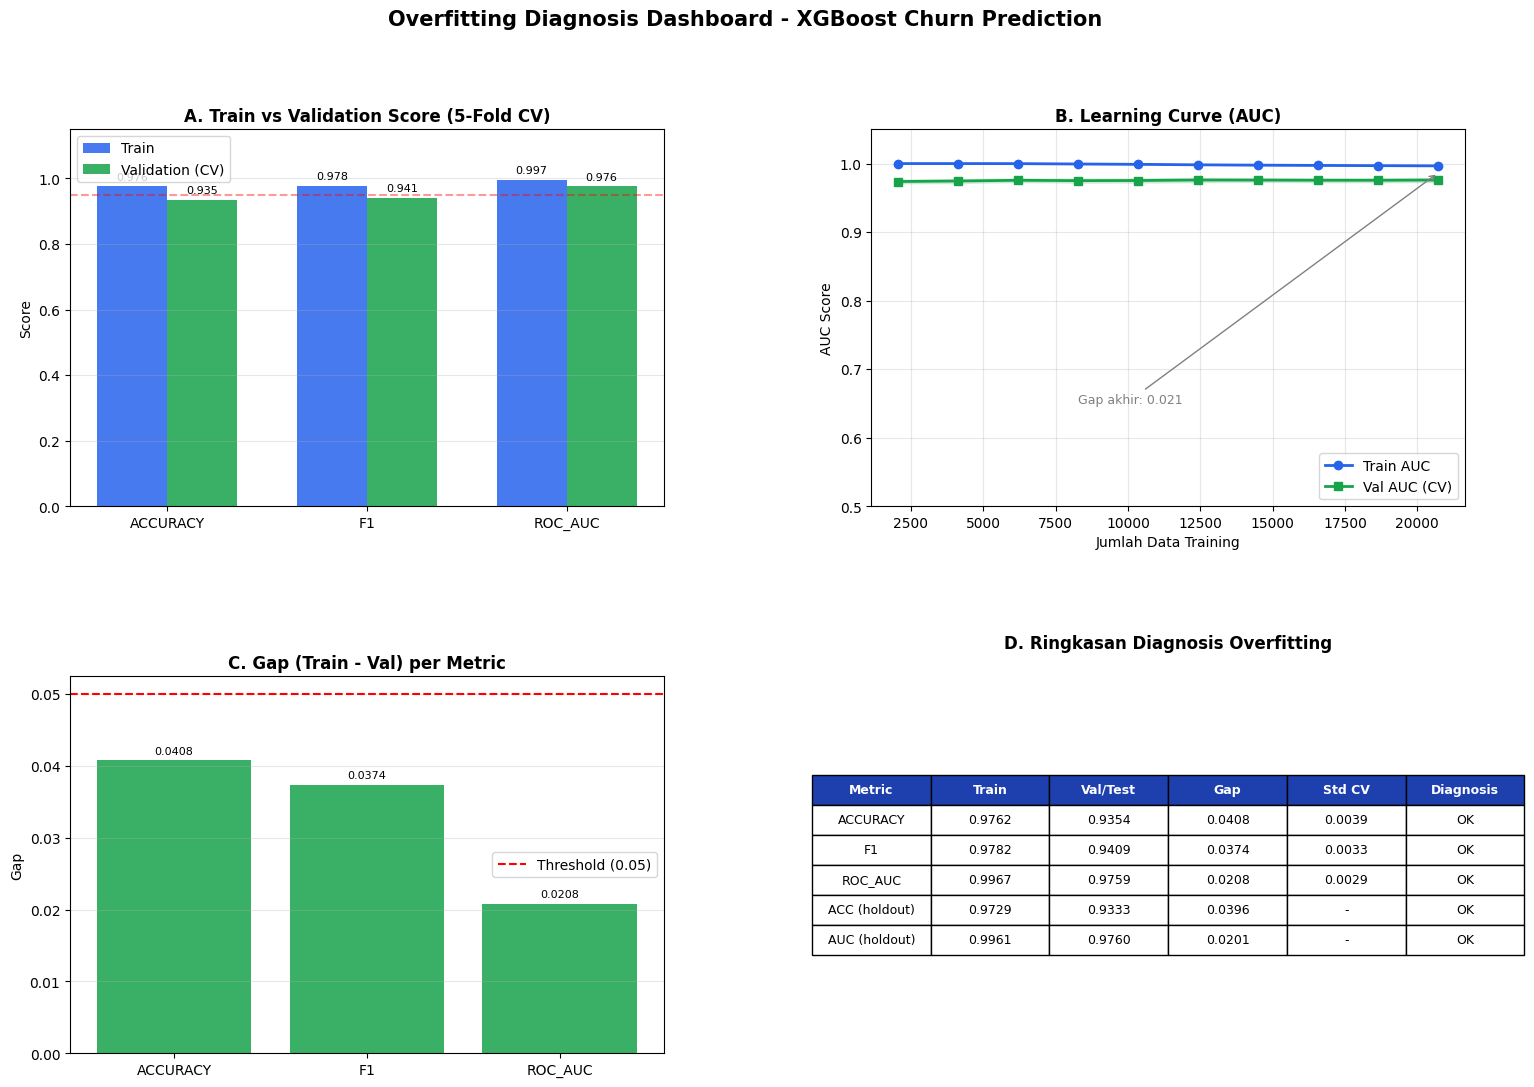


KESIMPULAN AKHIR
  OK: Model TIDAK overfitting.
  Semua gap (train - val) berada di bawah threshold 5%.
  Model generalizes dengan baik ke data baru.


In [102]:
# =============================================================================
# CELL 7B: CEK OVERFITTING MODEL XGBOOST
# =============================================================================
#
# Penjelasan Overfitting:
# Overfitting terjadi ketika model terlalu "hafal" data training sehingga
# performa di data training sangat tinggi, tetapi buruk di data baru.
# Analogi: mahasiswa yang menghafal soal lama tapi gagal saat soal berubah.
#
# Tiga metode deteksi:
#   1. Train vs Test Accuracy (holdout 80/20) -- langsung pakai xgb_model
#   2. Stratified 5-Fold Cross-Validation
#   3. Learning Curve (AUC vs ukuran data training)
#
# Interpretasi:
#   - Gap train-val < 5%  -->  OK, model generalizes dengan baik
#   - Gap train-val > 5%  -->  WARNING: kemungkinan overfitting
#   - Std antar fold > 3% -->  Model tidak stabil antar subset data
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier

# --- Threshold overfitting ---------------------------------------------------
THRESHOLD = 0.05   # gap 5%
CV_FOLDS  = 5

# =============================================================================
# METODE 1: TRAIN vs TEST ACCURACY (Holdout)
# Gunakan xgb_model yang sudah dilatih di cell sebelumnya.
# Bandingkan skor di data training vs testing.
# Jika gap besar -> model hafal training, gagal di test -> OVERFITTING.
# =============================================================================
print("=" * 60)
print("METODE 1: TRAIN vs TEST ACCURACY (Holdout 80/20)")
print("=" * 60)

train_acc = accuracy_score(y_train, xgb_model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  xgb_model.predict(X_test_scaled))
train_auc = roc_auc_score(y_train,  xgb_model.predict_proba(X_train_scaled)[:, 1])
test_auc  = roc_auc_score(y_test,   xgb_model.predict_proba(X_test_scaled)[:, 1])

gap_acc = train_acc - test_acc
gap_auc = train_auc - test_auc

print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Test  Accuracy : {test_acc:.4f}")
print(f"  Gap Accuracy   : {gap_acc:.4f}  -->  {'WARNING: OVERFITTING' if gap_acc > THRESHOLD else 'OK'}")
print()
print(f"  Train AUC      : {train_auc:.4f}")
print(f"  Test  AUC      : {test_auc:.4f}")
print(f"  Gap AUC        : {gap_auc:.4f}  -->  {'WARNING: OVERFITTING' if gap_auc > THRESHOLD else 'OK'}")

# =============================================================================
# METODE 2: STRATIFIED K-FOLD CROSS-VALIDATION
# Data dibagi 5 bagian; tiap bagian bergantian menjadi test set.
# Lebih andal dari satu kali split karena setiap baris data pernah ditest.
# Std kecil = model stabil; gap train-val kecil = tidak overfitting.
# =============================================================================
print()
print("=" * 60)
print(f"METODE 2: {CV_FOLDS}-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)

cv_model = XGBClassifier(
    n_estimators=150, learning_rate=0.1, max_depth=6,
    min_child_weight=1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, use_label_encoder=False, eval_metric="logloss"
)
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
cv_results = cross_validate(
    cv_model, X_train_scaled, y_train, cv=skf,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=True, n_jobs=-1,
)

cv_summary = {}
for metric in ["accuracy", "f1", "roc_auc"]:
    tr  = cv_results[f"train_{metric}"]
    te  = cv_results[f"test_{metric}"]
    gap = tr.mean() - te.mean()
    if gap > THRESHOLD:
        status = "WARNING: OVERFITTING"
    elif te.std() > 0.03:
        status = "WARNING: TIDAK STABIL"
    else:
        status = "OK"
    cv_summary[metric] = {"train": tr.mean(), "val": te.mean(), "gap": gap, "std": te.std()}
    print(f"  [{metric.upper()}]")
    print(f"    Train  : {tr.mean():.4f} +/- {tr.std():.4f}")
    print(f"    Val CV : {te.mean():.4f} +/- {te.std():.4f}")
    print(f"    Gap    : {gap:.4f}  -->  {status}")

# =============================================================================
# METODE 3: LEARNING CURVE
# Latih model dengan berbagai ukuran data (10% s/d 100%).
# Plot AUC train vs validation. Jika keduanya konvergen -> model sehat.
# Jika gap lebar & tidak menyempit -> overfitting.
# =============================================================================
print()
print("=" * 60)
print("METODE 3: LEARNING CURVE")
print("=" * 60)

lc_model = XGBClassifier(
    n_estimators=150, learning_rate=0.1, max_depth=6,
    min_child_weight=1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, use_label_encoder=False, eval_metric="logloss"
)
train_sizes_abs, train_scores_lc, val_scores_lc = learning_curve(
    lc_model, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc", n_jobs=-1,
)
train_mean_lc = train_scores_lc.mean(axis=1)
train_std_lc  = train_scores_lc.std(axis=1)
val_mean_lc   = val_scores_lc.mean(axis=1)
val_std_lc    = val_scores_lc.std(axis=1)
final_gap_lc  = train_mean_lc[-1] - val_mean_lc[-1]
print(f"  Gap AUC di 100% data training: {final_gap_lc:.4f}  -->  {'WARNING: OVERFITTING' if final_gap_lc > THRESHOLD else 'OK'}")

# =============================================================================
# DASHBOARD VISUALISASI (4 Panel)
# Panel A: Bar chart Train vs Val per metric (CV)
# Panel B: Learning Curve AUC
# Panel C: Gap bar chart (merah = overfitting, hijau = OK)
# Panel D: Tabel ringkasan diagnosis
# =============================================================================
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Overfitting Diagnosis Dashboard - XGBoost Churn Prediction",
             fontsize=15, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Panel A: Bar Chart Train vs Val
ax_a = fig.add_subplot(gs[0, 0])
metrics_list = list(cv_summary.keys())
train_vals   = [cv_summary[m]["train"] for m in metrics_list]
val_vals     = [cv_summary[m]["val"]   for m in metrics_list]
x            = np.arange(len(metrics_list))
bars_t = ax_a.bar(x - 0.175, train_vals, 0.35, label="Train",           color="#2563EB", alpha=0.85)
bars_v = ax_a.bar(x + 0.175, val_vals,   0.35, label="Validation (CV)", color="#16A34A", alpha=0.85)
ax_a.bar_label(bars_t, fmt="%.3f", padding=3, fontsize=8)
ax_a.bar_label(bars_v, fmt="%.3f", padding=3, fontsize=8)
ax_a.set_xticks(x)
ax_a.set_xticklabels([m.upper() for m in metrics_list])
ax_a.set_ylim(0, 1.15)
ax_a.set_title("A. Train vs Validation Score (5-Fold CV)", fontweight="bold")
ax_a.set_ylabel("Score")
ax_a.legend()
ax_a.axhline(0.95, color="red", linestyle="--", alpha=0.4, label="Ref 0.95")
ax_a.grid(axis="y", alpha=0.3)

# Panel B: Learning Curve
ax_b = fig.add_subplot(gs[0, 1])
ax_b.plot(train_sizes_abs, train_mean_lc, "o-", color="#2563EB", label="Train AUC",    lw=2)
ax_b.fill_between(train_sizes_abs, train_mean_lc - train_std_lc, train_mean_lc + train_std_lc,
                  alpha=0.15, color="#2563EB")
ax_b.plot(train_sizes_abs, val_mean_lc,   "s-", color="#16A34A", label="Val AUC (CV)", lw=2)
ax_b.fill_between(train_sizes_abs, val_mean_lc - val_std_lc, val_mean_lc + val_std_lc,
                  alpha=0.15, color="#16A34A")
ax_b.set_xlabel("Jumlah Data Training")
ax_b.set_ylabel("AUC Score")
ax_b.set_title("B. Learning Curve (AUC)", fontweight="bold")
ax_b.legend(loc="lower right")
ax_b.set_ylim(0.5, 1.05)
ax_b.grid(alpha=0.3)
ax_b.annotate(
    f"Gap akhir: {final_gap_lc:.3f}",
    xy=(train_sizes_abs[-1], (train_mean_lc[-1] + val_mean_lc[-1]) / 2),
    xytext=(train_sizes_abs[3], 0.65),
    arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9, color="gray",
)

# Panel C: Gap Bar Chart
ax_c = fig.add_subplot(gs[1, 0])
gaps   = [cv_summary[m]["gap"] for m in metrics_list]
colors = ["#EF4444" if g > THRESHOLD else "#16A34A" for g in gaps]
bars_g = ax_c.bar([m.upper() for m in metrics_list], gaps, color=colors, alpha=0.85)
ax_c.bar_label(bars_g, fmt="%.4f", padding=3, fontsize=8)
ax_c.axhline(THRESHOLD, color="red", linestyle="--", lw=1.5, label=f"Threshold ({THRESHOLD})")
ax_c.set_title("C. Gap (Train - Val) per Metric", fontweight="bold")
ax_c.set_ylabel("Gap")
ax_c.legend()
ax_c.grid(axis="y", alpha=0.3)

# Panel D: Tabel Ringkasan
ax_d = fig.add_subplot(gs[1, 1])
ax_d.axis("off")
rows = []
for m in metrics_list:
    s = cv_summary[m]
    if s["gap"] > THRESHOLD:
        diag = "OVERFITTING"
    elif s["std"] > 0.03:
        diag = "TIDAK STABIL"
    else:
        diag = "OK"
    rows.append([m.upper(), f"{s['train']:.4f}", f"{s['val']:.4f}",
                 f"{s['gap']:.4f}", f"{s['std']:.4f}", diag])
rows.append(["ACC (holdout)", f"{train_acc:.4f}", f"{test_acc:.4f}",
             f"{gap_acc:.4f}", "-", "OVERFITTING" if gap_acc > THRESHOLD else "OK"])
rows.append(["AUC (holdout)", f"{train_auc:.4f}", f"{test_auc:.4f}",
             f"{gap_auc:.4f}", "-", "OVERFITTING" if gap_auc > THRESHOLD else "OK"])

col_labels = ["Metric", "Train", "Val/Test", "Gap", "Std CV", "Diagnosis"]
tbl = ax_d.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor("#1E40AF")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i, row in enumerate(rows, start=1):
    color = "#FEE2E2" if "OVERFITTING" in row[-1] else ("#FEF3C7" if "STABIL" in row[-1] else "white")
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(color)
ax_d.set_title("D. Ringkasan Diagnosis Overfitting", fontweight="bold", pad=20)

plt.tight_layout()
import os as _os
_os.makedirs("../reports", exist_ok=True)
plt.savefig("../reports/overfitting_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()

# =============================================================================
# VERDICT AKHIR
# =============================================================================
print()
print("=" * 60)
print("KESIMPULAN AKHIR")
print("=" * 60)
all_ok = (
    all(cv_summary[m]["gap"] <= THRESHOLD and cv_summary[m]["std"] <= 0.03
        for m in metrics_list)
    and gap_acc <= THRESHOLD
    and gap_auc <= THRESHOLD
)
if all_ok:
    print("  OK: Model TIDAK overfitting.")
    print("  Semua gap (train - val) berada di bawah threshold 5%.")
    print("  Model generalizes dengan baik ke data baru.")
else:
    print("  WARNING: Model kemungkinan OVERFITTING. Saran perbaikan:")
    print("  1. Turunkan max_depth dari 6 menjadi 3-4")
    print("  2. Naikkan min_child_weight dari 1 menjadi 3-5")
    print("  3. Tambah regularisasi: reg_alpha=0.1, reg_lambda=1.5")
    print("  4. Gunakan learning_rate=0.05 + n_estimators=300")


In [103]:
# =============================================================================
# CELL 8: TRAINING MODEL — LOGISTIC REGRESSION
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

print("🔄 Handling remaining NaNs for Logistic Regression...")
# Logistic Regression cannot handle NaNs. We use an imputer to fill any gaps.
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

print("🔄 Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_imputed, y_train)

# Prediksi
y_pred_lr       = lr_model.predict(X_test_imputed)
y_pred_proba_lr = lr_model.predict_proba(X_test_imputed)[:, 1]

print("✅ Logistic Regression selesai!")
print(f"   Training samples : {X_train_imputed.shape[0]}")
print(f"   Test samples     : {X_test_imputed.shape[0]}")

🔄 Handling remaining NaNs for Logistic Regression...
🔄 Training Logistic Regression...
✅ Logistic Regression selesai!
   Training samples : 25894
   Test samples     : 11098


In [104]:
# =============================================================================
# CELL 9: TRAINING MODEL — RANDOM FOREST
# =============================================================================

from sklearn.ensemble import RandomForestClassifier

print("🔄 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf       = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Random Forest selesai!")
print(f"   Training samples : {X_train_scaled.shape[0]}")
print(f"   Test samples     : {X_test_scaled.shape[0]}")


🔄 Training Random Forest...
✅ Random Forest selesai!
   Training samples : 25894
   Test samples     : 11098


📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Not Churn       0.94      0.91      0.93      5094
       Churn       0.93      0.95      0.94      6004

    accuracy                           0.93     11098
   macro avg       0.93      0.93      0.93     11098
weighted avg       0.93      0.93      0.93     11098


🎯 ROC-AUC Score: 0.9760


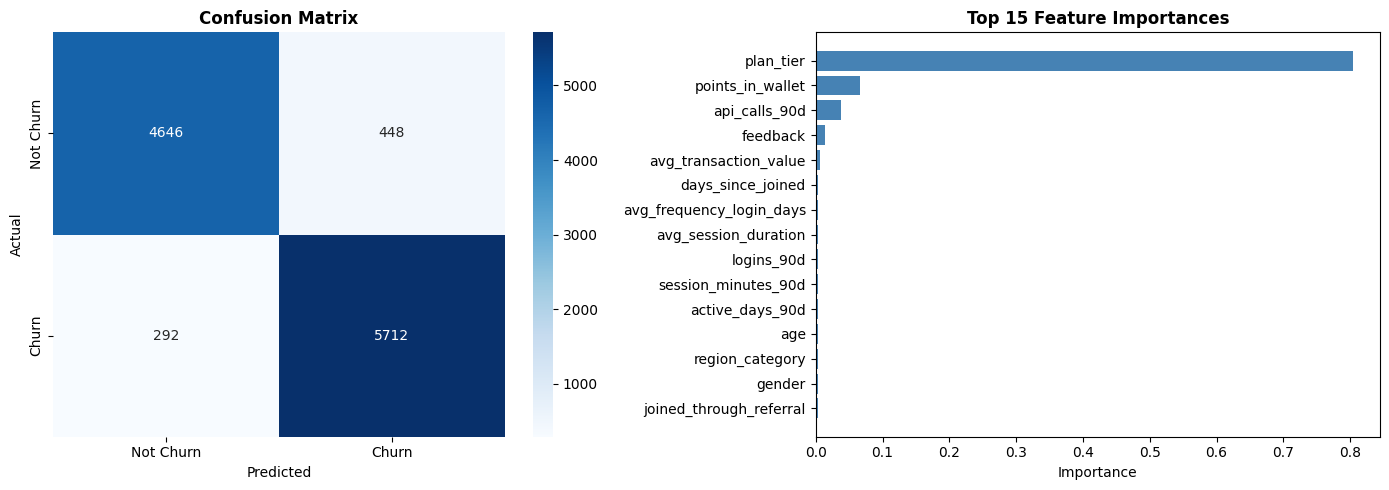

In [105]:
# =============================================================================
# CELL 10: EVALUASI MODEL
# =============================================================================

# 1. Classification Report
print("=" * 60)
print("📊 CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Not Churn', 'Churn']))

# 2. ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n🎯 ROC-AUC Score: {roc_auc:.4f}")

# 3. Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance (Top 15)
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=True).tail(15)

axes[1].barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
axes[1].set_title('Top 15 Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [106]:
# =============================================================================
# CELL 11: EVALUASI MODEL — LOGISTIC REGRESSION
# =============================================================================

from sklearn.metrics import classification_report, roc_auc_score

print("=" * 60)
print("📊 CLASSIFICATION REPORT — LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=["Not Churn", "Churn"]))

roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"🎯 ROC-AUC Score: {roc_auc_lr:.4f}")


📊 CLASSIFICATION REPORT — LOGISTIC REGRESSION
              precision    recall  f1-score   support

   Not Churn       0.81      0.91      0.86      5094
       Churn       0.91      0.82      0.86      6004

    accuracy                           0.86     11098
   macro avg       0.86      0.87      0.86     11098
weighted avg       0.87      0.86      0.86     11098

🎯 ROC-AUC Score: 0.9441


In [107]:
# =============================================================================
# CELL 12: EVALUASI MODEL — RANDOM FOREST
# =============================================================================

from sklearn.metrics import classification_report, roc_auc_score

print("=" * 60)
print("📊 CLASSIFICATION REPORT — RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=["Not Churn", "Churn"]))

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"🎯 ROC-AUC Score: {roc_auc_rf:.4f}")


📊 CLASSIFICATION REPORT — RANDOM FOREST
              precision    recall  f1-score   support

   Not Churn       0.91      0.94      0.93      5094
       Churn       0.95      0.92      0.94      6004

    accuracy                           0.93     11098
   macro avg       0.93      0.93      0.93     11098
weighted avg       0.93      0.93      0.93     11098

🎯 ROC-AUC Score: 0.9746


🔄 Menghitung SHAP values untuk XGBoost...
✅ SHAP values dihitung! Shape: (11098, 24)

📊 Plot 1: SHAP Beeswarm Summary Plot


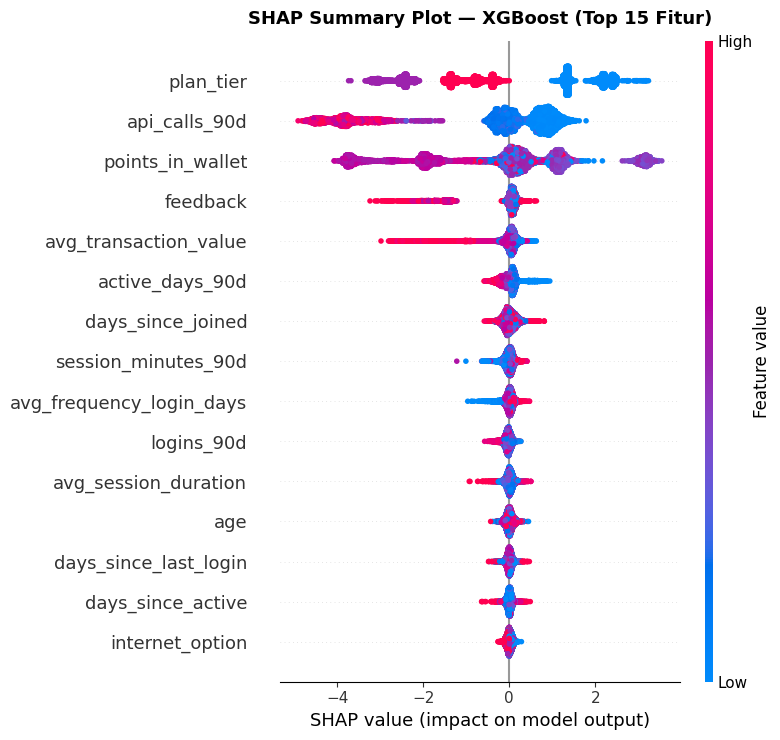


📊 Plot 2: SHAP Feature Importance (Mean |SHAP|)


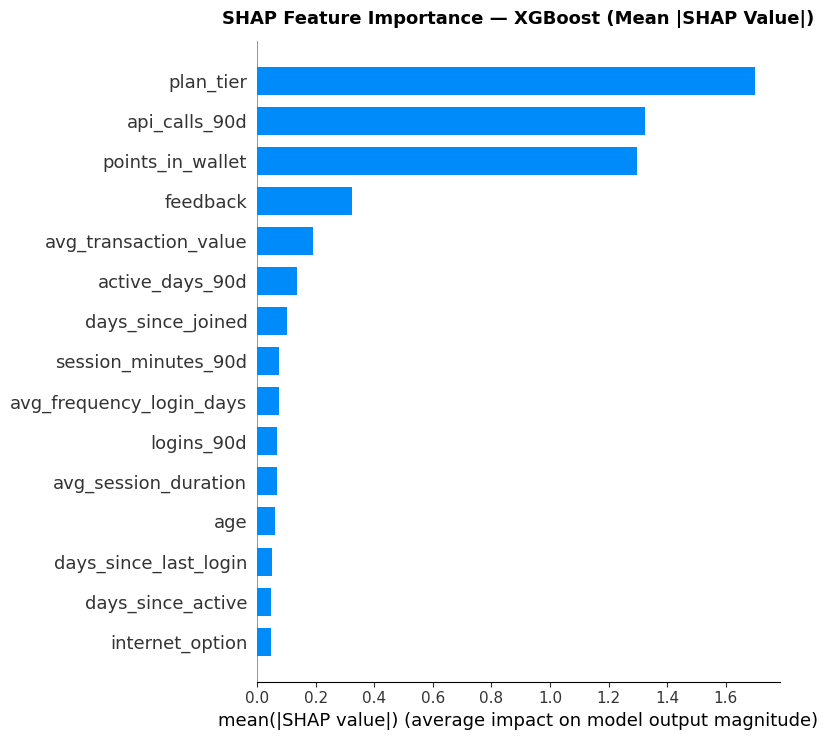


📊 Plot 3: Waterfall — Pelanggan risiko churn tertinggi


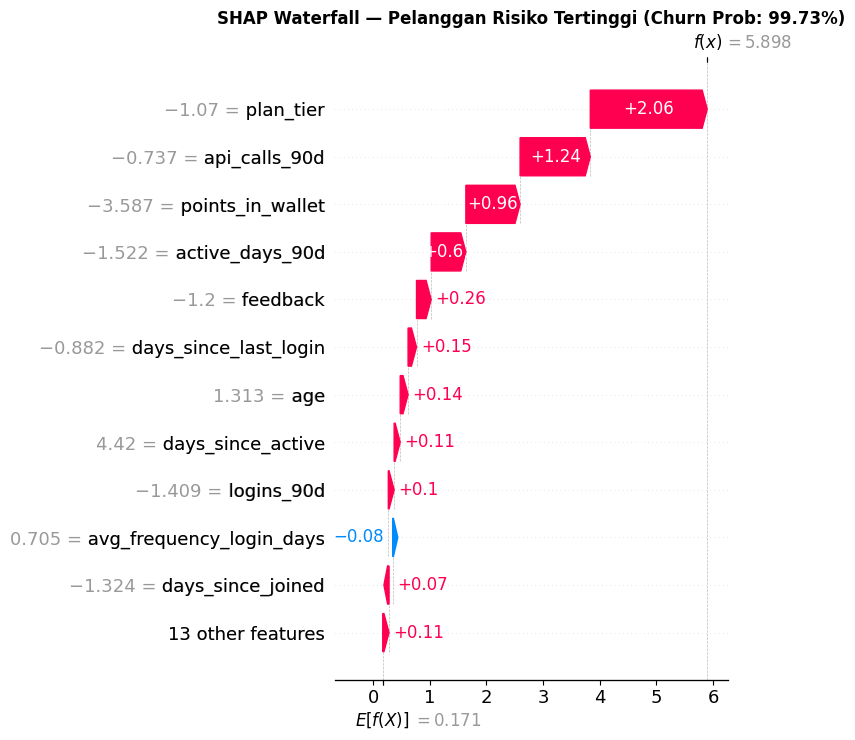


🔍 TOP 10 FITUR BERDASARKAN SHAP (XGBoost)
                 Feature  Mean |SHAP|
               plan_tier     1.700022
           api_calls_90d     1.323461
        points_in_wallet     1.295739
                feedback     0.325173
   avg_transaction_value     0.191571
         active_days_90d     0.138262
       days_since_joined     0.103870
     session_minutes_90d     0.076221
avg_frequency_login_days     0.074276
              logins_90d     0.068675

✅ SHAP analysis selesai!


In [108]:
# =============================================================================
# CELL 13: SHAP EXPLAINABILITY — XGBoost
# =============================================================================

import importlib, subprocess
if importlib.util.find_spec("shap") is None:
    print("📦 Installing shap...")
    subprocess.run(["pip", "install", "shap", "-q"], check=True)
    print("✅ shap installed!")

import shap
import pandas as pd
import matplotlib.pyplot as plt

print("🔄 Menghitung SHAP values untuk XGBoost...")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
X_test_df   = pd.DataFrame(X_test_scaled, columns=feature_names)
print(f"✅ SHAP values dihitung! Shape: {shap_values.shape}")

# ── Plot 1: Beeswarm Summary Plot ────────────────────────────────────────────
print("\n📊 Plot 1: SHAP Beeswarm Summary Plot")
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, plot_type="dot", max_display=15, show=False)
plt.title("SHAP Summary Plot — XGBoost (Top 15 Fitur)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Plot 2: Bar Plot (Mean |SHAP|) ───────────────────────────────────────────
print("\n📊 Plot 2: SHAP Feature Importance (Mean |SHAP|)")
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Feature Importance — XGBoost (Mean |SHAP Value|)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── Plot 3: Waterfall untuk pelanggan risiko tertinggi ───────────────────────
print("\n📊 Plot 3: Waterfall — Pelanggan risiko churn tertinggi")
high_risk_idx = y_pred_proba.argmax()
shap_explanation = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test_df.iloc[high_risk_idx].values,
    feature_names = feature_names
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, max_display=12, show=False)
plt.title(
    f"SHAP Waterfall — Pelanggan Risiko Tertinggi (Churn Prob: {y_pred_proba[high_risk_idx]:.2%})",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ── Tabel Top Fitur ───────────────────────────────────────────────────────────
mean_shap = pd.DataFrame({
    "Feature"    : feature_names,
    "Mean |SHAP|": abs(shap_values).mean(axis=0)
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("🔍 TOP 10 FITUR BERDASARKAN SHAP (XGBoost)")
print("="*50)
print(mean_shap.head(10).to_string(index=False))
print("="*50)
print("\n✅ SHAP analysis selesai!")


In [109]:
# =============================================================================
# CELL 16: PREVIEW REPORT - SVM CHURN PREDICTION
# =============================================================================

import pandas as pd
import numpy as np

# ─── Bangun report_df dari df_original + hasil SVM ───────────────────────────
# Cari kolom ID pelanggan jika ada
id_col   = next((c for c in df_original.columns if c.lower() in
                 ['customer_id','customerid','id','cust_id','no']), None)
name_col = next((c for c in df_original.columns if c.lower() in
                 ['name','nama','customer_name','custname']), None)
fb_col   = next((c for c in df_original.columns if c.lower() in
                 ['feedback','comment','review','komentar','ulasan']), None)

def get_risk_level(prob):
    if prob >= 0.80: return "🔴 Sangat Tinggi"
    if prob >= 0.60: return "🟠 Tinggi"
    if prob >= 0.40: return "🟡 Sedang"
    return "🟢 Rendah"

def get_solusi(prob, feedback_text=""):
    if prob >= 0.80:
        return "Hubungi pelanggan segera, tawarkan retensi khusus / diskon loyalitas."
    if prob >= 0.60:
        return "Kirim survei kepuasan + follow-up personal dalam 3 hari."
    if prob >= 0.40:
        return "Monitor aktivitas, kirim notifikasi promo atau program poin."
    return "Pertahankan pengalaman positif, pertimbangkan program referral."

def get_masalah(prob):
    if prob >= 0.80: return "Ketidakpuasan tinggi – risiko churn sangat kritis."
    if prob >= 0.60: return "Indikasi kuat pelanggan tidak puas dengan layanan."
    if prob >= 0.40: return "Sinyal peringatan dini – perlu perhatian lebih lanjut."
    return "Tidak terdeteksi masalah signifikan."

report_df = df_original.copy()

# Pastikan kolom SVM tersedia (jalankan Cell 4 jika belum)
if 'svm_churn_prob' not in report_df.columns:
    raise RuntimeError("Kolom 'svm_churn_prob' tidak ditemukan. Pastikan Cell 4 (SVM) sudah dijalankan.")

# Normalisasi nama kolom
report_df['Customer_ID']              = report_df[id_col].astype(str)   if id_col   else report_df.index.astype(str)
report_df['Nama']                     = report_df[name_col].astype(str) if name_col else 'N/A'
report_df['Feedback_Original']        = report_df[fb_col].astype(str)   if fb_col   else '-'
report_df['Churn_Probability']        = report_df['svm_churn_prob']
report_df['Churn_Probability_Percent']= (report_df['svm_churn_prob'] * 100).round(2)
report_df['Prediksi']                 = report_df['svm_churn_label']
report_df['Risk_Level']               = report_df['svm_churn_prob'].apply(get_risk_level)
report_df['Masalah']                  = report_df['svm_churn_prob'].apply(get_masalah)
report_df['Solusi']                   = report_df['svm_churn_prob'].apply(get_solusi)
report_df['Kesimpulan']               = report_df.apply(
    lambda r: f"Pelanggan diprediksi {'CHURN' if r['svm_churn_pred']==1 else 'TIDAK CHURN'} "
              f"dengan probabilitas {r['Churn_Probability_Percent']}% berdasarkan analisis feedback via SVM.",
    axis=1
)

# ─── Tampilkan Preview ────────────────────────────────────────────────────────
print("=" * 80)
print("📋 PREVIEW REPORT - 5 PELANGGAN DENGAN RISIKO CHURN TERTINGGI")
print("=" * 80)

high_risk = report_df.nlargest(5, 'Churn_Probability')

for idx, row in high_risk.iterrows():
    print(f"\n{'─' * 70}")
    cust_label = f"{row['Customer_ID']}" + (f" | {row['Nama']}" if row['Nama'] != 'N/A' else '')
    print(f"👤 Pelanggan #{idx}  —  {cust_label}")
    print(f"{'─' * 70}")
    print(f"📊 Churn Probability : {row['Churn_Probability_Percent']}%")
    print(f"🏷️  Prediksi          : {row['Prediksi']}")
    print(f"⚠️   Risk Level        : {row['Risk_Level']}")
    fb = str(row['Feedback_Original'])
    print(f"💬 Feedback          : {fb[:100]}..." if len(fb) > 100 else f"💬 Feedback          : {fb}")
    print(f"\n❌ MASALAH  : {row['Masalah']}")
    print(f"✅ SOLUSI   : {row['Solusi']}")
    print(f"\n📝 KESIMPULAN: {row['Kesimpulan']}")

print(f"\n{'=' * 80}")
print(f"Total pelanggan dianalisis  : {len(report_df)}")
churn_count    = int(report_df['svm_churn_pred'].sum())
no_churn_count = len(report_df) - churn_count
print(f"Prediksi Churn              : {churn_count} pelanggan ({churn_count/len(report_df)*100:.1f}%)")
print(f"Prediksi Tidak Churn        : {no_churn_count} pelanggan ({no_churn_count/len(report_df)*100:.1f}%)")
print(f"{'=' * 80}")


📋 PREVIEW REPORT - 5 PELANGGAN DENGAN RISIKO CHURN TERTINGGI

──────────────────────────────────────────────────────────────────────
👤 Pelanggan #67  —  67
──────────────────────────────────────────────────────────────────────
📊 Churn Probability : 99.74%
🏷️  Prediksi          : Churn
⚠️   Risk Level        : 🔴 Sangat Tinggi
💬 Feedback          : Too many ads

❌ MASALAH  : Ketidakpuasan tinggi – risiko churn sangat kritis.
✅ SOLUSI   : Hubungi pelanggan segera, tawarkan retensi khusus / diskon loyalitas.

📝 KESIMPULAN: Pelanggan diprediksi CHURN dengan probabilitas 99.74% berdasarkan analisis feedback via SVM.

──────────────────────────────────────────────────────────────────────
👤 Pelanggan #12880  —  12880
──────────────────────────────────────────────────────────────────────
📊 Churn Probability : 99.69%
🏷️  Prediksi          : Churn
⚠️   Risk Level        : 🔴 Sangat Tinggi
💬 Feedback          : Too many ads

❌ MASALAH  : Ketidakpuasan tinggi – risiko churn sangat kritis.
✅ SOLUSI  

🔄 Menyiapkan Decision Tree & Cross Validation...

📊 HASIL CROSS-VALIDATION (10-Fold) - DECISION TREE
Skor Akurasi tiap Fold : [0.92046332 0.93166023 0.93050193 0.92432432 0.93008884 0.92313635
 0.93433758 0.92777134 0.93086134 0.93279258]
Rata-rata Akurasi      : 0.9286 (+/- 0.0086)

🏆 TOP 10 ATRIBUT PALING BERPENGARUH (HUBUNGAN KE TARGET)
                Fitur  Tingkat Kepentingan
        api_calls_90d             0.707120
     points_in_wallet             0.289265
            plan_tier             0.002882
           logins_90d             0.000586
avg_transaction_value             0.000148
                  age             0.000000
      region_category             0.000000
               gender             0.000000
days_since_last_login             0.000000
      internet_option             0.000000


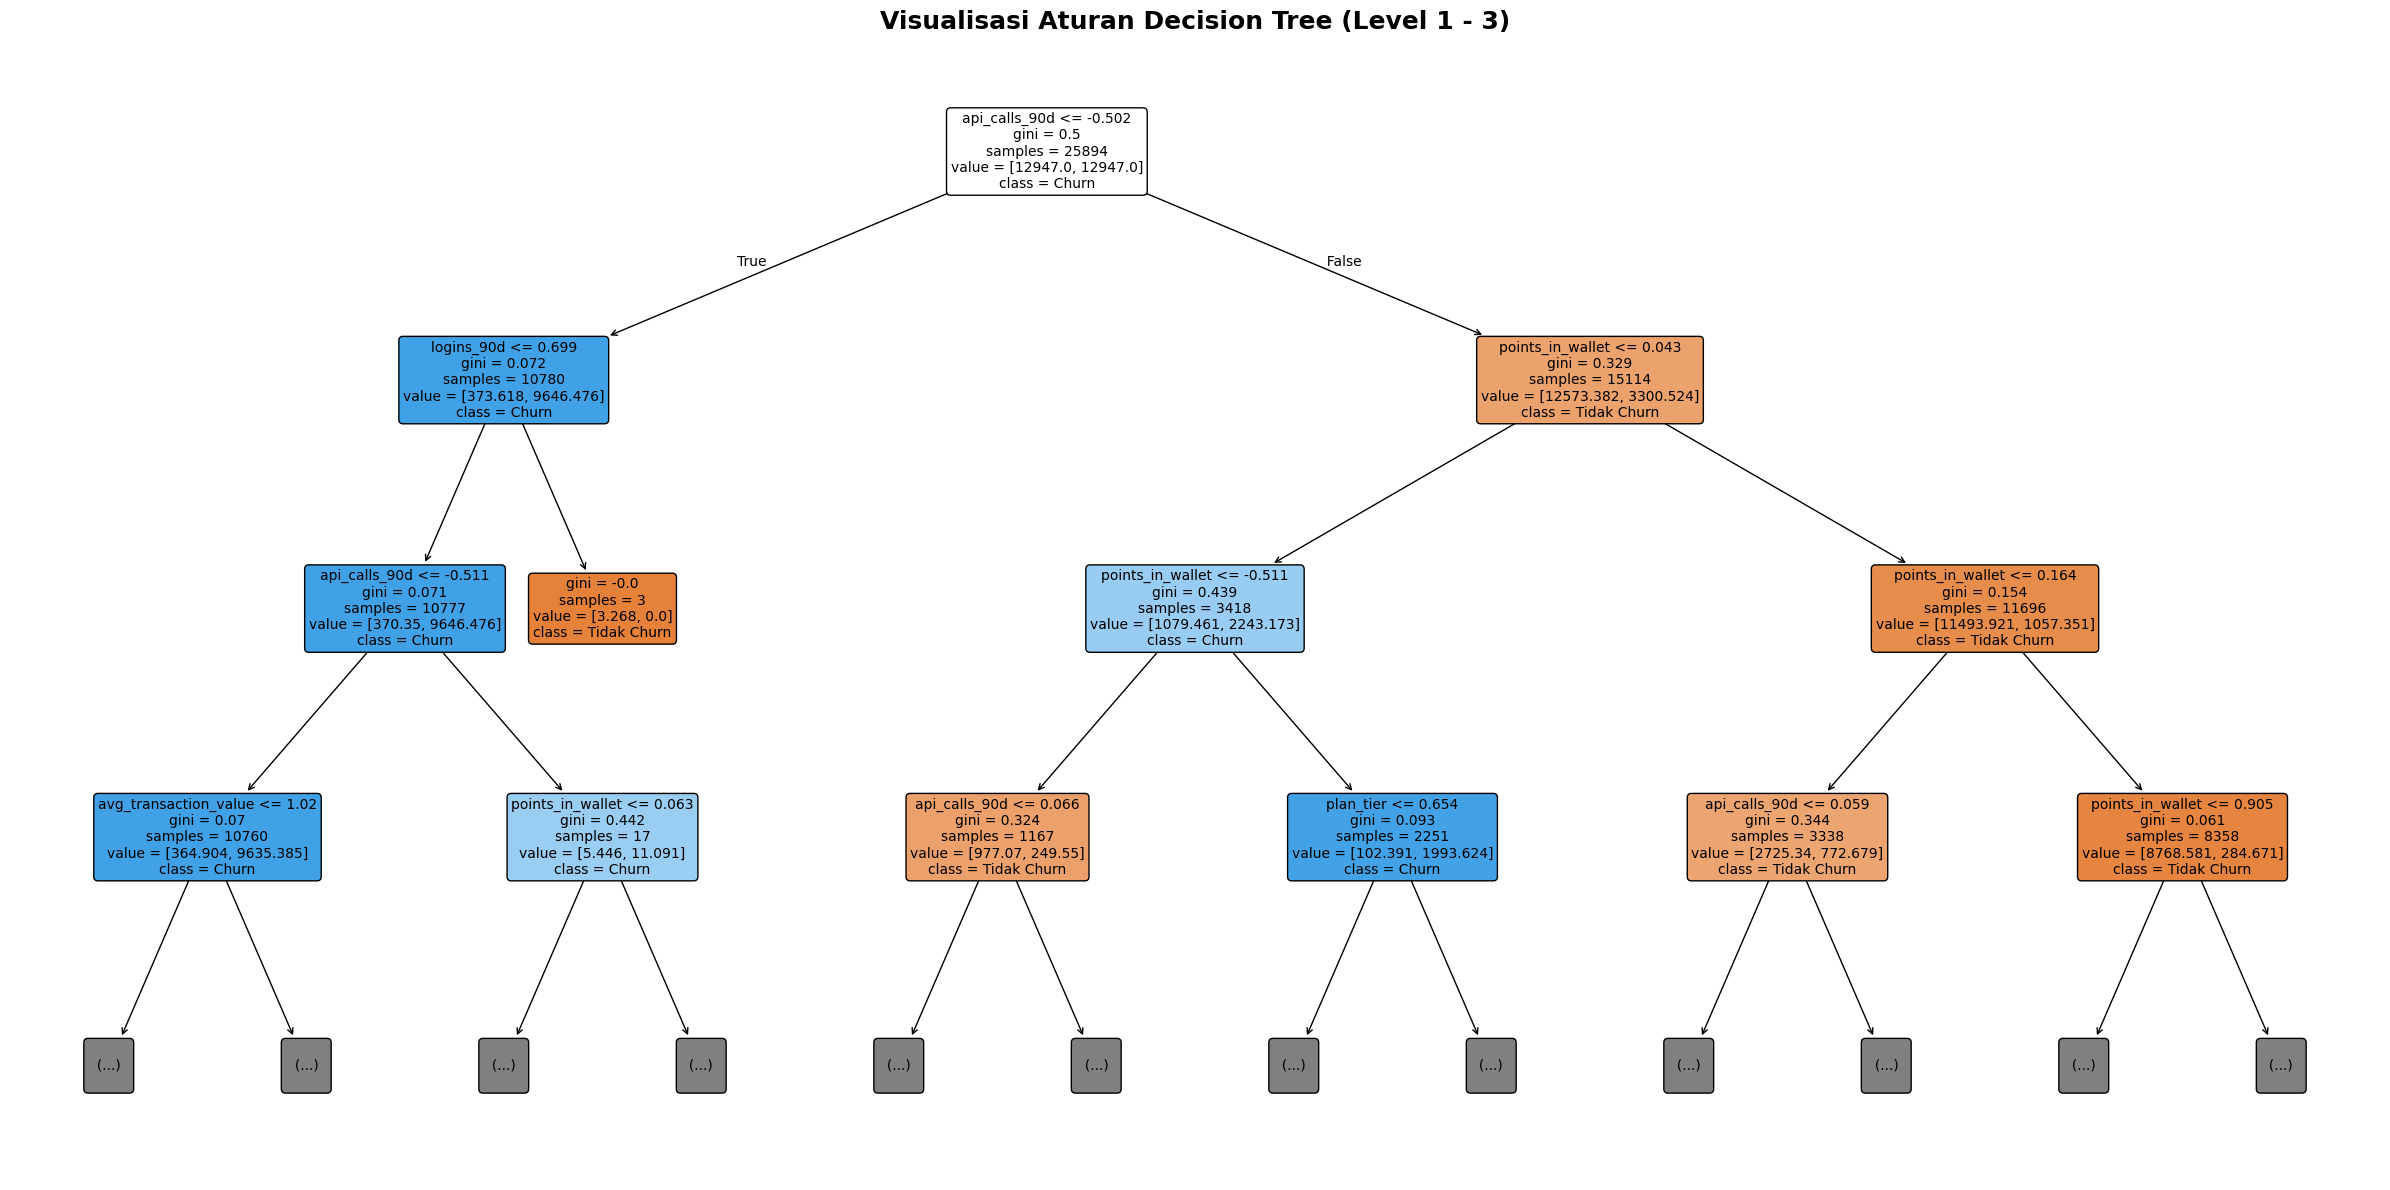

In [110]:
# =============================================================================
# CELL 10: DECISION TREE, CROSS VALIDATION, & VISUALISASI
# =============================================================================
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd
import numpy as np

print("🔄 Menyiapkan Decision Tree & Cross Validation...")

# 1. Inisialisasi Model Decision Tree
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt_model.fit(X_train_scaled, y_train)

# 2. Proses Cross-Validation (K-Fold = 10)
# Menggunakan StratifiedKFold untuk memastikan proporsi kelas target konsisten
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# Menggunakan StratifiedKFold untuk memastikan proporsi kelas target konsisten
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print("\n" + "="*60)
print("📊 HASIL CROSS-VALIDATION (10-Fold) - DECISION TREE")
print("="*60)
print(f"Skor Akurasi tiap Fold : {cv_scores}")
print(f"Rata-rata Akurasi      : {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# 3. Menghitung Hubungan/Pentingnya Atribut (Feature Importance)
importances = dt_model.feature_importances_
feature_df = pd.DataFrame({'Fitur': feature_names, 'Tingkat Kepentingan': importances})
feature_df = feature_df.sort_values(by='Tingkat Kepentingan', ascending=False).head(10)

print("\n" + "="*60)
print("🏆 TOP 10 ATRIBUT PALING BERPENGARUH (HUBUNGAN KE TARGET)")
print("="*60)
print(feature_df.to_string(index=False))

# 4. Visualisasi Decision Tree (Pohon Keputusan)
plt.figure(figsize=(24, 12))
plot_tree(dt_model, 
          feature_names=feature_names,  
          class_names=['Tidak Churn', 'Churn'],
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3)
plt.title('Visualisasi Aturan Decision Tree (Level 1 - 3)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


🔄 Menghitung Prediksi Cross-Validation untuk Matriks Evaluasi...

📈 METRIK EVALUASI: SENSITIVITY & SPECIFICITY (10-Fold CV)
Sensitivity (Recall Positif) : 0.8981 (89.8%)
Specificity (Recall Negatif) : 0.9646 (96.5%)
------------------------------------------------------------
Interpretasi:
- 89.8% pelanggan yang BENAR-BENAR CHURN berhasil ditebak oleh model.
- 96.5% pelanggan yang TIDAK CHURN berhasil ditebak dengan benar.


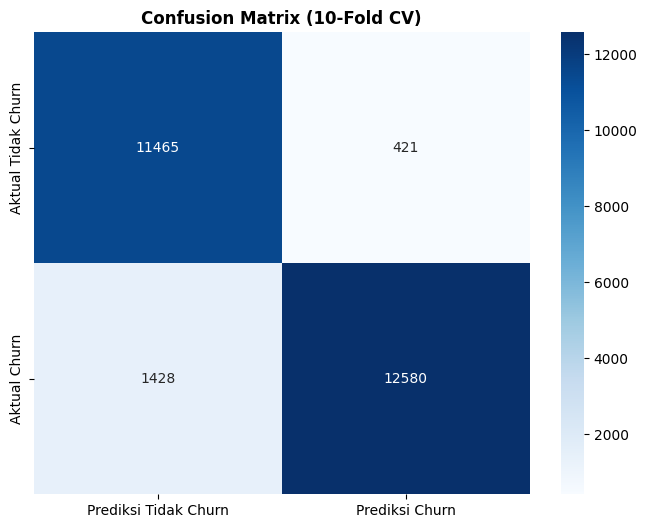

In [111]:
# =============================================================================
# CELL 11: EVALUASI MENDALAM (SENSITIVITY & SPECIFICITY)
# =============================================================================
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("🔄 Menghitung Prediksi Cross-Validation untuk Matriks Evaluasi...")
# Mendapatkan hasil prediksi dari 10-Fold CV
y_pred_cv = cross_val_predict(dt_model, X_train_scaled, y_train, cv=skf)

# Menghitung Confusion Matrix
cm_cv = confusion_matrix(y_train, y_pred_cv)
tn, fp, fn, tp = cm_cv.ravel()

# Menghitung Metrik
sensitivity = tp / (tp + fn)  # Sama dengan Recall untuk kelas positif
specificity = tn / (tn + fp)  # Recall untuk kelas negatif

print("\n" + "="*60)
print("📈 METRIK EVALUASI: SENSITIVITY & SPECIFICITY (10-Fold CV)")
print("="*60)
print(f"Sensitivity (Recall Positif) : {sensitivity:.4f} ({sensitivity*100:.1f}%)")
print(f"Specificity (Recall Negatif) : {specificity:.4f} ({specificity*100:.1f}%)")
print("-"*60)
print("Interpretasi:")
print(f"- {sensitivity*100:.1f}% pelanggan yang BENAR-BENAR CHURN berhasil ditebak oleh model.")
print(f"- {specificity*100:.1f}% pelanggan yang TIDAK CHURN berhasil ditebak dengan benar.")

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prediksi Tidak Churn', 'Prediksi Churn'], 
            yticklabels=['Aktual Tidak Churn', 'Aktual Churn'])
plt.title('Confusion Matrix (10-Fold CV)', fontweight='bold')
plt.show()


🔄 Menyiapkan Evaluasi untuk XGBOOST...

📊 HASIL CROSS-VALIDATION (10-Fold) - XGBOOST
Rata-rata Akurasi      : 0.9338 (+/- 0.0109)

📈 METRIK EVALUASI: SENSITIVITY & SPECIFICITY - XGBOOST
Sensitivity (Recall Positif) : 0.9515 (95.1%)
Specificity (Recall Negatif) : 0.9129 (91.3%)


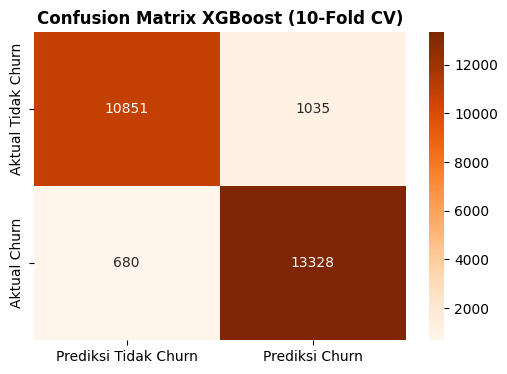

In [112]:
# =============================================================================
# CELL 12: EVALUASI MENDALAM KHUSUS MODEL XGBOOST
# =============================================================================
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("🔄 Menyiapkan Evaluasi untuk XGBOOST...")

# 1. Inisialisasi Model XGBoost
# Menggunakan parameter standar, bisa disesuaikan jika sudah di-tuning
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Proses Cross-Validation (K-Fold = 10 Stratified)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_xgb = cross_val_score(xgb_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print("\n" + "="*60)
print("📊 HASIL CROSS-VALIDATION (10-Fold) - XGBOOST")
print("="*60)
print(f"Rata-rata Akurasi      : {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std() * 2:.4f})")

# 3. Prediksi dan Metrik (Sensitivity & Specificity)
y_pred_cv_xgb = cross_val_predict(xgb_model, X_train_scaled, y_train, cv=skf)
cm_xgb = confusion_matrix(y_train, y_pred_cv_xgb)
tn_x, fp_x, fn_x, tp_x = cm_xgb.ravel()

sensitivity_xgb = tp_x / (tp_x + fn_x)
specificity_xgb = tn_x / (tn_x + fp_x)

print("\n" + "="*60)
print("📈 METRIK EVALUASI: SENSITIVITY & SPECIFICITY - XGBOOST")
print("="*60)
print(f"Sensitivity (Recall Positif) : {sensitivity_xgb:.4f} ({sensitivity_xgb*100:.1f}%)")
print(f"Specificity (Recall Negatif) : {specificity_xgb:.4f} ({specificity_xgb*100:.1f}%)")

# Visualisasi Confusion Matrix XGBoost
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Prediksi Tidak Churn', 'Prediksi Churn'], 
            yticklabels=['Aktual Tidak Churn', 'Aktual Churn'])
plt.title('Confusion Matrix XGBoost (10-Fold CV)', fontweight='bold')
plt.show()


In [113]:
# =============================================================================
# CELL 13: VISUALISASI RULE XGBOOST (POHON PERTAMA)
# =============================================================================
import xgboost as xgb
import matplotlib.pyplot as plt

print("🔄 Menarik aturan (rules) dari model XGBoost...")
# Melatih ulang model pada seluruh data training agar rule bisa diekstrak
xgb_model.fit(X_train_scaled, y_train)

# Karena XGBoost memiliki ratusan pohon, kita akan melihat representasi pohon pertama (Tree 0)
booster = xgb_model.get_booster()
try:
    booster.feature_names = list(feature_names) # Memasukkan nama fitur agar tidak sekadar f0, f1
except:
    pass

tree_dump = booster.get_dump()[0]

print("\n" + "="*60)
print("🌲 TEXT RULES DARI POHON PERTAMA (TREE 0) XGBOOST")
print("="*60)
print("Cara membaca: [Kondisi Fitur] yes=Cabang selanjutnya jika YA, no=Cabang jika TIDAK\n")
print(tree_dump)
print("-"*60)

print("Mencoba menggambar pohon secara visual (membutuhkan modul 'graphviz')...")
try:
    fig, ax = plt.subplots(figsize=(24, 12))
    xgb.plot_tree(xgb_model, num_trees=0, ax=ax, rankdir='LR')
    plt.title('Visualisasi Rule XGBoost (Pohon Ke-0)', fontsize=18, fontweight='bold')
    plt.show()
except Exception as e:
    print("\n⚠️ Gagal menggambar diagram pohon karena graphviz belum terinstall/terkonfigurasi di sistem OS Anda.")
    print(f"Pesan Error: {e}")
    print("\n💡 TIPS: Anda tetap bisa menganalisis jalannya logika XGBoost melalui 'TEXT RULES' di atas.")


🔄 Menarik aturan (rules) dari model XGBoost...

🌲 TEXT RULES DARI POHON PERTAMA (TREE 0) XGBOOST
Cara membaca: [Kondisi Fitur] yes=Cabang selanjutnya jika YA, no=Cabang jika TIDAK

0:[plan_tier<0.0794978812] yes=1,no=2,missing=2
	1:[session_minutes_90d<0.556818724] yes=3,no=4,missing=4
		3:leaf=0.517333031
		4:[avg_session_duration<-0.0477935076] yes=7,no=8,missing=8
			7:leaf=0.468579471
			8:[session_minutes_90d<0.61275202] yes=13,no=14,missing=14
				13:leaf=-0.195762783
				14:leaf=0.352444947
	2:[points_in_wallet<0.0429962352] yes=5,no=6,missing=6
		5:[points_in_wallet<-0.511360526] yes=9,no=10,missing=10
			9:[plan_tier<1.22886586] yes=15,no=16,missing=16
				15:leaf=-0.648458481
				16:[points_in_wallet<-1.61428034] yes=23,no=24,missing=24
					23:[feedback<0.367563784] yes=33,no=34,missing=34
						33:leaf=0.107707307
						34:leaf=-0.280250192
					24:[points_in_wallet<-1.48984373] yes=35,no=36,missing=36
						35:leaf=-0.237056091
						36:leaf=-0.50737536
			10:[plan_tier<1.